### 生成数据

In [19]:
import numpy as np
import torch

# 设置随机数种子，使得每次运行代码生成的数据相同
np.random.seed(42)

# 生成随机数据
x = np.random.rand(100, 1)  # 生成 100 个 0~1 之间的随机数，作为输入特征 x
y = 1 + 2 * x + 0.1 * np.random.randn(100, 1)  # 根据 y = 1 + 2x 生成目标值，并加入少量随机噪声模拟真实数据

# 将数据转换为 pytorch tensor
x_tensor = torch.from_numpy(x).float()  # 将 NumPy 数组转换为 PyTorch Tensor，并转为 float32 类型
y_tensor = torch.from_numpy(y).float()  # 将目标值 y 转换为 PyTorch Tensor，并转为 float32 类型

### 设置超参数

In [20]:
learning_rate = 0.1
num_epochs = 1000

### 初始化线性回归模型的参数

In [21]:
# 随机初始化权重 w，并开启梯度计算，训练时用于自动更新参数
w = torch.randn(1, requires_grad=True)

# 将偏置 b 初始化为 0，并开启梯度计算
b = torch.zeros(1, requires_grad=True)

### 开始训练

In [22]:
for epoch in range(num_epochs):
    y_pred = x_tensor * w + b  # 前向传播：根据当前参数 w、b 计算预测值
    loss = ((y_pred - y_tensor) ** 2).mean()  # 计算均方误差损失 MSE
    loss.backward()  # 反向传播：计算 loss 对 w、b 的梯度

    # 更新模型参数
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

        # 清空梯度，避免下一轮训练时梯度累加
        w.grad.zero_()
        b.grad.zero_()

# 输出训练完成后的模型参数
print('w:', w)
print('b:', b)

w: tensor([1.9540], requires_grad=True)
b: tensor([1.0215], requires_grad=True)


### 可视化

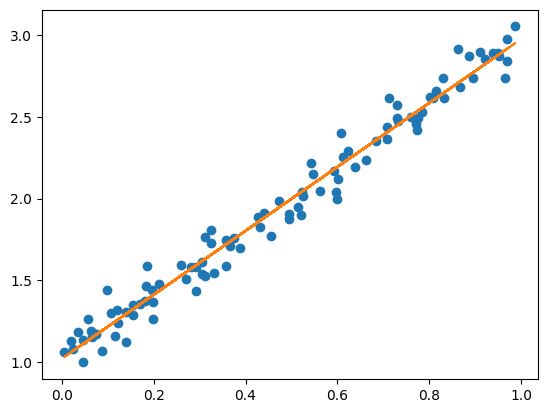

In [23]:
import matplotlib.pyplot as plt
plt.plot(x, y, 'o')  # 绘制原始数据点，'o' 表示使用圆点显示样本
# 绘制模型预测结果，detach() 用于从计算图中分离张量，再转换为 NumPy 数组
plt.plot(x_tensor.numpy(), y_pred.detach().numpy())
plt.show()

### PyTorch实现线性回归

In [24]:
import numpy as np
import torch
import torch.nn as nn
np.random.seed(42)

x = np.random.rand(100, 1)  # 生成 100 个 0~1 之间的随机输入数据
y = 1 + 2 * x + 0.1 * np.random.randn(100, 1)  # 按照 y = 1 + 2x 生成目标值，并加入少量随机噪声

# 将 NumPy 数组转换为 PyTorch Tensor，并转为 float32 类型
x_tensor = torch.from_numpy(x).float()
y_tensor = torch.from_numpy(y).float()

# 设置训练超参数
learning_rate = 0.1   # 学习率：控制每次参数更新的步长
num_epochs = 1000     # 训练轮数：完整训练数据的次数

# 定义输入数据和输出数据的维度
input_dim = 1    # 每个样本有 1 个输入特征
output_dim = 1   # 模型输出 1 个预测值

# 定义线性回归模型，nn.Linear 会自动创建并管理权重 weight 和偏置 bias
model = nn.Linear(input_dim, output_dim)

# 定义损失函数：均方误差 MSE
criterion = nn.MSELoss()

# 定义优化器：使用随机梯度下降 SGD 更新模型参数
optimizer = torch.optim.SGD(
    model.parameters(),     # 指定需要优化的模型参数
    lr=learning_rate        # 使用设定的学习率
)

# 开始训练
for epoch in range(num_epochs):
    y_pred = model(x_tensor)              # 前向传播：将输入数据传入模型，得到预测值
    loss = criterion(y_pred, y_tensor)    # 计算预测值与真实值之间的均方误差损失
    optimizer.zero_grad()                 # 清空上一轮训练产生的梯度，防止梯度累加
    loss.backward()                       # 反向传播：计算模型参数对应的梯度
    optimizer.step()                      # 根据计算得到的梯度更新模型参数

# 输出训练完成后的权重和偏置
print('w:', model.weight.data)
print('b:', model.bias.data)

w: tensor([[1.9540]])
b: tensor([1.0215])
